# **Modelo 4**

Dataset: **dataset_caracteristicas_train_V1_ALL.csv**

## OBJETIVO DEL NOTEBOOK

El objetivo es responder la siguiente pregunta:

> ***Aprendió el modelo a detectar voz sintética como concepto general, o solo memorizó los patrones de los 4 primeros ataques?***

### Como lo hicimos:
| Fase | Ataques incluidos | Rol |
|------|-------------------|-----|
| **Entrenamiento** | A01, A02, A03, A04 (spoof) + bonafide | Lo que el modelo ve |
| **Test** | A05, A06 (spoof) + bonafide | Lo que el modelo nunca vió |

### Configuración:
- **Algoritmo:** XGBoost optimizado
- **Hiperparámetros:** `XGB_OPTIMAL_PARAMS_M1`
- **Features:** 13 features óptimas (de las 34 originales)
- **N óptimo:** 4,000 muestras

### ***Bloque 1: importamos las librerias y hacemos la configuración global***

In [1]:
#  Bloque 1: importaciones y configuración global

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
import json
import os
warnings.filterwarnings('ignore')

from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate, learning_curve
from sklearn.preprocessing import LabelEncoder
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, roc_curve
)

sns.set_theme(style='whitegrid', palette='Set2', font_scale=1.15)
plt.rcParams['figure.dpi']       = 110
plt.rcParams['axes.titleweight'] = 'bold'

RANDOM_STATE = 42
N_FOLDS      = 5
DATA_PATH    = '../Obtencion_Metricas/dataset_caracteristicas_train_V1_ALL.csv'

# Configuración train/test
TRAIN_ATTACKS = ['A01', 'A02', 'A03', 'A04']
TEST_ATTACKS  = ['A05', 'A06']

# Hiperparámetros óptimos de XGBoost (RandomizedSearchCV, Modelo 1, N = 4.000)
XGB_OPTIMAL_PARAMS_M1 = {
    'objective'         : 'binary:logistic',
    'eval_metric'       : 'logloss',
    'use_label_encoder' : False,
    'random_state'      : RANDOM_STATE,
    'n_jobs'            : -1,
    'n_estimators'      : 620,
    'max_depth'         : 7,
    'learning_rate'     : 0.09591931665418388,
    'subsample'         : 0.602208846849441,
    'colsample_bytree'  : 0.6379995910112717,
    'reg_alpha'         : 0.7722447692966574,
    'reg_lambda'        : 1.3942205669037757,
    'min_child_weight'  : 1,
}

# 13 features óptimas del modelo 3 (Permutation Importance sobre XGBoost optimizado)
FINAL_FEATURES = [
    'signal_mean', 'mfcc_9_std', 'mfcc_6_mean', 'mfcc_7_mean',
    'mfcc_4_std', 'mfcc_5_mean', 'mfcc_13_mean', 'mfcc_2_std',
    'mfcc_8_std', 'mfcc_3_mean', 'mfcc_10_std', 'mfcc_9_mean',
    'mfcc_11_mean'
]

print(f'  Ataques de TRAIN : {TRAIN_ATTACKS}')
print(f'  Ataques de TEST  : {TEST_ATTACKS}')
print(f'  Algoritmo        : XGBoost optimizado')
print(f'  Hiperparámetros  : XGB_OPTIMAL_PARAMS_M1 (Modelo 1)')
print(f'  Features         : {len(FINAL_FEATURES)} features óptimas (Permutation Importance, Modelo 3)')

  Ataques de TRAIN : ['A01', 'A02', 'A03', 'A04']
  Ataques de TEST  : ['A05', 'A06']
  Algoritmo        : XGBoost optimizado
  Hiperparámetros  : XGB_OPTIMAL_PARAMS_M2 (Modelo 2)
  Features         : 13 features óptimas (Permutation Importance, Modelo 3)


## **SECCIÓN 1: Construcción del Dataset por grupos de ataque**

En los modelos 1 y 3 la separación train/test era **aleatoria estratificada**: ambos conjuntos contenían muestras de todos los ataques. En este notebook, en cambio, la separación es **estructural por ataque**: el test contiene ataques que el modelo nunca vió. Esto simula el escenario real donde aparecen nuevos sistemas TTS en producción.

Vamos a realizar una separación con **train perfectamente balanceado de 4.000 muestras** (2.000 spoof A01-A04 + 2.000 bonafide) y un **test sellado de 1.000 muestras** (500 spoof A05-A06 + 500 bonafide).

### ***Bloque 2: carga del dataset y partición por grupos de ataque (llamamos ataque un tipo de algoritmo de IA que generó audios sinteticos)***

In [2]:
#  Bloque 2: carga y partición por grupo de ataque

df_full = pd.read_csv(DATA_PATH)

print(f'Total registros : {len(df_full):,}')
print(f'Columnas        : {list(df_full.columns)}')
print()
print('Distribución por attack_id:')
print(df_full['attack_id'].value_counts().sort_index())
print()
print('Distribución por label:')
print(df_full['label'].value_counts())

Total registros : 25,380
Columnas        : ['file_name', 'signal_mean', 'signal_std', 'rmse_mean', 'zcr_mean', 'tempo_bpm', 'mfcc_1_mean', 'mfcc_1_std', 'mfcc_2_mean', 'mfcc_2_std', 'mfcc_3_mean', 'mfcc_3_std', 'mfcc_4_mean', 'mfcc_4_std', 'mfcc_5_mean', 'mfcc_5_std', 'mfcc_6_mean', 'mfcc_6_std', 'mfcc_7_mean', 'mfcc_7_std', 'mfcc_8_mean', 'mfcc_8_std', 'mfcc_9_mean', 'mfcc_9_std', 'mfcc_10_mean', 'mfcc_10_std', 'mfcc_11_mean', 'mfcc_11_std', 'mfcc_12_mean', 'mfcc_12_std', 'mfcc_13_mean', 'mfcc_13_std', 'spectral_centroid_mean', 'spectral_bandwidth_mean', 'spectral_rolloff_mean', 'attack_id', 'label']

Distribución por attack_id:
attack_id
-      2580
A01    3800
A02    3800
A03    3800
A04    3800
A05    3800
A06    3800
Name: count, dtype: int64

Distribución por label:
label
spoof       22800
bonafide     2580
Name: count, dtype: int64


### ***Bloque 3: separación y undersampling balanceado (TRAIN: A01-A04 | TEST: A05-A06)***

In [3]:
#  Bloque 3: separación y undersampling balanceado (TRAIN: A01-A04 | TEST: A05-A06)

# Parámetros de balanceo: 4.000 train (50/50) + 1.000 test sellado (50/50)
N_PER_CLASS_TRAIN = 2000   # muestras por clase en TRAIN = 2000 spoof + 2000 bonafide = 4.000
N_PER_CLASS_TEST  = 500    # muestras por clase en TEST = 500 spoof + 500 bonafide = 1.000

df_bonafide = df_full[df_full['label'] == 'bonafide'].copy()
df_spoof    = df_full[df_full['label'] == 'spoof'].copy()

# Spoof: separar por grupo de ataque
df_spoof_train_raw = df_spoof[df_spoof['attack_id'].isin(TRAIN_ATTACKS)].copy()
df_spoof_test_raw  = df_spoof[df_spoof['attack_id'].isin(TEST_ATTACKS)].copy()

# TRAIN: undersampling proporcional por ataque
attack_counts_tr = df_spoof_train_raw['attack_id'].value_counts()
props_tr         = attack_counts_tr / attack_counts_tr.sum()
n_per_atk_tr     = (props_tr * N_PER_CLASS_TRAIN).astype(int)
deficit_tr       = N_PER_CLASS_TRAIN - n_per_atk_tr.sum()
for atk in n_per_atk_tr.nlargest(abs(deficit_tr)).index:
    n_per_atk_tr[atk] += int(np.sign(deficit_tr))

spoof_train_parts = []
for atk, n in n_per_atk_tr.items():
    subset = df_spoof_train_raw[df_spoof_train_raw['attack_id'] == atk]
    spoof_train_parts.append(subset.sample(n=min(n, len(subset)), random_state=RANDOM_STATE))
df_spoof_train = pd.concat(spoof_train_parts)

# TEST: undersampling proporcional por ataque
attack_counts_te = df_spoof_test_raw['attack_id'].value_counts()
props_te         = attack_counts_te / attack_counts_te.sum()
n_per_atk_te     = (props_te * N_PER_CLASS_TEST).astype(int)
deficit_te       = N_PER_CLASS_TEST - n_per_atk_te.sum()
for atk in n_per_atk_te.nlargest(abs(deficit_te)).index:
    n_per_atk_te[atk] += int(np.sign(deficit_te))

spoof_test_parts = []
for atk, n in n_per_atk_te.items():
    subset = df_spoof_test_raw[df_spoof_test_raw['attack_id'] == atk]
    spoof_test_parts.append(subset.sample(n=min(n, len(subset)), random_state=RANDOM_STATE))
df_spoof_test = pd.concat(spoof_test_parts)

# Bonafide: dividir proporcionalmente train/test
df_bon_shuffled = df_bonafide.sample(frac=1, random_state=RANDOM_STATE)
prop_train_bon  = N_PER_CLASS_TRAIN / (N_PER_CLASS_TRAIN + N_PER_CLASS_TEST)
n_bon_train     = int(len(df_bon_shuffled) * prop_train_bon)

df_bon_train_raw = df_bon_shuffled.iloc[:n_bon_train]
df_bon_test_raw  = df_bon_shuffled.iloc[n_bon_train:]

# Undersample bonafide al mismo N_PER_CLASS de cada set
df_bon_train = df_bon_train_raw.sample(
    n=min(N_PER_CLASS_TRAIN, len(df_bon_train_raw)), random_state=RANDOM_STATE
)
df_bon_test = df_bon_test_raw.sample(
    n=min(N_PER_CLASS_TEST, len(df_bon_test_raw)), random_state=RANDOM_STATE
)

# Construir sets finales balanceados y mezclar
df_train = pd.concat([df_spoof_train, df_bon_train]).sample(
    frac=1, random_state=RANDOM_STATE).reset_index(drop=True)
df_test  = pd.concat([df_spoof_test,  df_bon_test]).sample(
    frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

ALL_FEATURE_COLS = [c for c in df_full.columns if c not in ['file_name', 'attack_id', 'label']]

X_train = df_train[FINAL_FEATURES]
y_train = df_train['label']
X_test  = df_test[FINAL_FEATURES]
y_test  = df_test['label']

le          = LabelEncoder().fit(['bonafide', 'spoof'])
y_train_enc = le.transform(y_train)
y_test_enc  = le.transform(y_test)

print('DATASET BALANCEADO (undersampling)')
print('-' * 68)
print(f'  TRAIN | Spoof (A01-A04): {len(df_spoof_train):>5,} | Bonafide: {len(df_bon_train):>5,} | Total: {len(df_train):>6,}')
print(f'  TEST  | Spoof (A05-A06): {len(df_spoof_test):>5,} | Bonafide: {len(df_bon_test):>5,} | Total: {len(df_test):>6,}')
print()
print('Distribución spoof en TRAIN (por ataque):')
print(df_train[df_train['label']=='spoof']['attack_id'].value_counts().sort_index().to_string())
print()
print('Distribución spoof en TEST - ataques nunca vistos:')
print(df_test[df_test['label']=='spoof']['attack_id'].value_counts().sort_index().to_string())
print()
print('Balance de clases en TRAIN:')
print(df_train['label'].value_counts().to_string())
print()
print('Balance de clases en TEST:')
print(df_test['label'].value_counts().to_string())
print()
print(f'Numero features utilizadas : {len(FINAL_FEATURES)} de {len(ALL_FEATURE_COLS)}')

DATASET BALANCEADO (undersampling)
--------------------------------------------------------------------
  TRAIN | Spoof (A01-A04): 2,000 | Bonafide: 2,000 | Total:  4,000
  TEST  | Spoof (A05-A06):   500 | Bonafide:   500 | Total:  1,000

Distribución spoof en TRAIN (por ataque):
attack_id
A01    500
A02    500
A03    500
A04    500

Distribución spoof en TEST - ataques nunca vistos:
attack_id
A05    250
A06    250

Balance de clases en TRAIN:
label
spoof       2000
bonafide    2000

Balance de clases en TEST:
label
bonafide    500
spoof       500

Numero features utilizadas : 13 de 34


## **SECCIÓN 2**: Entrenamiento del modelo final

La Learning Curve en esta sección tiene una lectura diferente a la learnign curve que hicimos en el modelo 1: en el modelo 1 intentamos encontrar un pleateau absoluto y encontramos un plateau "relativo", es decir 2.240 muestras es el numero de muestras a partir del cual, añadiendo muestras, el F1 crece a un ritmo más lento. 

Ahora estamos midiendo si el modelo aprende patrones **transferibles**: si la curva de validación sobre A01-A04 converge bien, significa que el modelo entendió la estructura del problema, no solo los ejemplos. El modelo final es el **XGBoost optimizado entrenado en A01-A04** y la pregunta que queremos responder es: ¿aprende algo transferible antes de ver A05-A06?

### ***Bloque 4: validación cruzada sobre conjunto de entrenamiento [(A01, A02, A03, A04) + bonafide]***

In [4]:
#  Bloque 4: VALIDACIÓN CRUZADA SOBRE TRAIN (A01-A04)

model = XGBClassifier(**XGB_OPTIMAL_PARAMS_M1)

cv_skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)

print(f'Ejecutando {N_FOLDS}-Fold CV sobre conjunto de TRAIN (A01-A04) + bonafide')
cv_results = cross_validate(
    model, X_train, y_train_enc,
    cv=cv_skf,
    scoring={'f1': 'f1', 'roc_auc': 'roc_auc', 'recall': 'recall', 'precision': 'precision'},
    return_train_score=True,
    n_jobs=-1
)

metrics_order = ['f1', 'roc_auc', 'recall', 'precision']
print()
print('VALIDACIÓN CRUZADA - conjunto de TRAIN (A01-A04) + bonafide')
print('-' * 62)
print(f'{"Métrica":<12} {"Train (μ)":>10} {"Val (μ)":>10} {"GAP":>8}')
print('-' * 44)
for m in metrics_order:
    tr  = cv_results[f'train_{m}'].mean()
    val = cv_results[f'test_{m}'].mean()
    gap = tr - val
    print(f'{m:<12} {tr:>10.4f} {val:>10.4f} {gap:>+8.4f}')
print()
model.fit(X_train, y_train_enc)
print('Hemos entrenado el modelo sobre todo el conjunto de TRAIN: (A01, A02, A03, A04) + bonafide')

Ejecutando 5-Fold CV sobre conjunto de TRAIN (A01-A04) + bonafide

VALIDACIÓN CRUZADA - conjunto de TRAIN (A01-A04) + bonafide
--------------------------------------------------------------
Métrica       Train (μ)    Val (μ)      GAP
--------------------------------------------
f1               1.0000     0.9445  +0.0555
roc_auc          1.0000     0.9874  +0.0126
recall           1.0000     0.9370  +0.0630
precision        1.0000     0.9523  +0.0477

Hemos entrenado el modelo sobre todo el conjunto de TRAIN: (A01, A02, A03, A04) + bonafide


## **SECCIÓN 3**: Learning Curve sobre el conjunto de TRAIN (A01, A02, A03, A04) + bonafide - algoritmo XGBoost optimizado

***Qué buscamos en esta Learning Curve?***

Si la curva de **validación** converge hacia la de **entrenamiento**, a medida que aumentan las muestras, el modelo está aprendiendo de manera correcta y hay esperanza que pueda generalizar bien en el conjunto de test (A05-A06);

- Si la curva de validación se estanca lejos de la de entrenamiento, la capacidad de generalización del modelo es limitada incluso dentro de A01-A04;

- Si las dos curvas se juntan con pocas muestras, el XGBoost es estable (buena señal de generalización futura).

***Como conectamos esto con el resultado en A05-A06?*** 

Si la Learning Curve muestra que la curva de entrenamiento y de validación convergen, pero el F1 en A05-A06 baja, el problema es que probablemente A05 y A06 tienen características acústicas distintas de A01-A04. 

Si la Learning Curve ya mostraba problemas, en el sentido que las dos curvas no convergen, y A05-A06 también falla, el problema es del modelo (por ejemplo, hay pocas features incuidas en el modelo).

***Que es que nos dice nuestro grafico de la learning curve?***

El gráfico demuestra que el modelo sí es capaz de generalizar muy bien para los ataques A01-A04 (saca un ~0.94 en validación cruzada).

Si al enfrentarse a A05-A06 el rendimiento se desploma, el culpable no es el modelo ni su falta de variables.

El culpable es lo que en ciencia de datos se llama **Domain Shift** (Cambio de Dominio): los audios A05 y A06 tienen firmas acústicas, ruidos o artefactos de falsificación que simplemente no existían en las muestras de A01 a A04. El modelo no puede predecir algo que nunca le enseñaron a reconocer.

### ***Bloque 5: LEARNING CURVE***

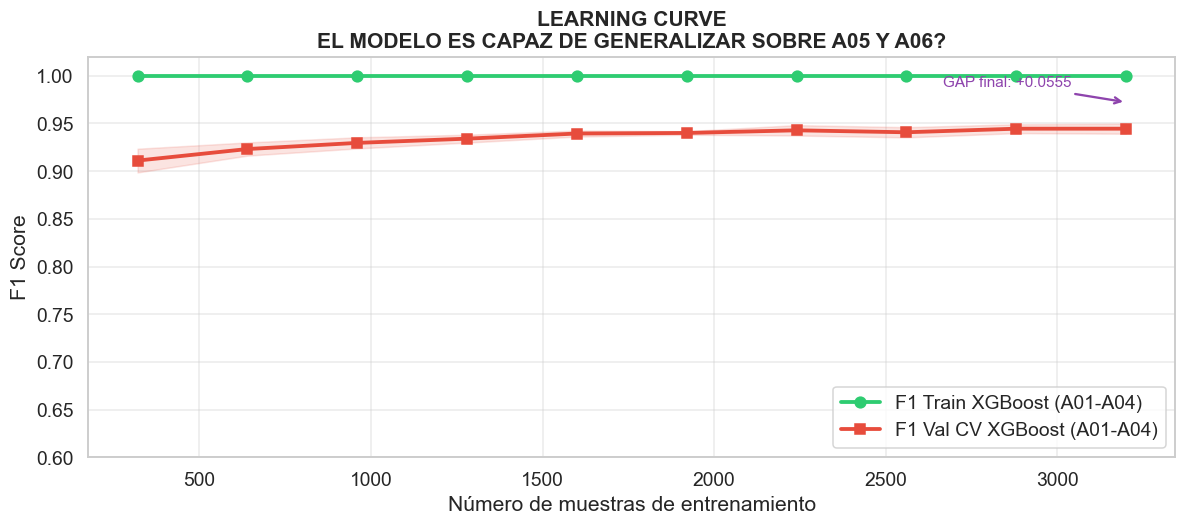

Gráfico guardado: modelo4_learning_curve.png
GAP final: +0.0555


In [5]:
# Bloque 5: LEARNING CURVE

train_sizes, train_scores, val_scores = learning_curve(
    XGBClassifier(**XGB_OPTIMAL_PARAMS_M1),
    X_train, y_train_enc,
    train_sizes=np.linspace(0.10, 1.0, 10),
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    scoring='f1',
    n_jobs=-1
)

tr_mean  = train_scores.mean(axis=1)
tr_std   = train_scores.std(axis=1)
val_mean = val_scores.mean(axis=1)
val_std  = val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(11, 5))

ax.plot(train_sizes, tr_mean,  'o-', color='#2ecc71', lw=2.5, ms=7, label='F1 Train XGBoost (A01-A04)')
ax.fill_between(train_sizes, tr_mean - tr_std,  tr_mean + tr_std,  alpha=0.15, color='#2ecc71')
ax.plot(train_sizes, val_mean, 's-', color='#e74c3c', lw=2.5, ms=7, label='F1 Val CV XGBoost (A01-A04)')
ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.15, color='#e74c3c')

ax.set_xlabel('Número de muestras de entrenamiento')
ax.set_ylabel('F1 Score')
ax.set_title('LEARNING CURVE\n'
             'EL MODELO ES CAPAZ DE GENERALIZAR SOBRE A05 Y A06?')
ax.legend(loc='lower right')
ax.set_ylim([0.60, 1.02])
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
ax.grid(True, alpha=0.4)

# Anotar el GAP final
gap_final = tr_mean[-1] - val_mean[-1]
ax.annotate(
    f'GAP final: {gap_final:+.4f}',
    xy=(train_sizes[-1], (tr_mean[-1] + val_mean[-1]) / 2),
    xytext=(-120, 10), textcoords='offset points',
    fontsize=10, color='#8e44ad',
    arrowprops=dict(arrowstyle='->', color='#8e44ad', lw=1.5)
)

plt.tight_layout()
plt.savefig('modelo4_learning_curve.png', bbox_inches='tight', dpi=120)
plt.show()
print('Gráfico guardado: modelo4_learning_curve.png')
print(f'GAP final: {gap_final:+.4f}')

## **SECCIÓN 4**: Evaluación sobre ataques no vistos (A05 y A06)

***Por qué evaluamos primero el conjunto completo A05+A06 y luego por separado?***

El resultado conjunto nos da la métrica global de generalización. El resultado por ataque individual revela qué sistema TTS/vocoder es más difícil de detectar: si el modelo falla más en A05 que en A06 (o viceversa), significa que esos dos ataques tienen características acústicas más distintas de A01-A04.

***Cómo interpretamos el resultado?*** 

- **F1 ≥ 0.85 en A05-A06**: el modelo generalizó muy bien. Aprendió la diferencia estructural entre voz humana y sintética;

- **F1 entre 0.70 y 0.85**: el modelo generalizó parcialmente . El modelo capturó parte del concepto pero también memorizó patrones de A01-A04;

- **F1 < 0.70**: el modelo sobreajustó a los 4 primeros ataques. 

***Cómo justificamos las Feature Importance en este contexto?***  

Si las features más importantes en el test de A05-A06 son las mismas que en el train de A01-A04, el modelo aprendió de manera robusta, o sea las features usadas son realmente las caracteristicas universales para detectar diferencias entre audios reales y audios sinteticos. 

Si las importancias cambian drásticamente, significa que el modelo está usando artefactos del vocoder en lugar de características universales de la voz sintética.

### ***Bloque 6: EVALUACIÓN GLOBAL EN TEST (A05 + A06)***

In [6]:
#  Bloque 6: EVALUACIÓN GLOBAL EN TEST (A05 + A06)

y_pred       = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

test_metrics = {
    'f1'       : f1_score(y_test_enc, y_pred),
    'roc_auc'  : roc_auc_score(y_test_enc, y_pred_proba),
    'recall'   : recall_score(y_test_enc, y_pred),
    'precision': precision_score(y_test_enc, y_pred),
    'accuracy' : accuracy_score(y_test_enc, y_pred)
}

# Métricas de referencia en train (CV)
cv_f1_val  = cv_results['test_f1'].mean()
cv_auc_val = cv_results['test_roc_auc'].mean()
gap_f1     = cv_f1_val - test_metrics['f1']
gap_auc    = cv_auc_val - test_metrics['roc_auc']

print('=' * 65)
print('RESULTADO GLOBAL EN ATAQUES NUNCA VISTOS (A05 + A06)')
print('=' * 65)
print(f'{"Métrica":<12} {"CV en A01-A04":>14} {"Test A05-A06":>14} {"Caída":>8}')
print('-' * 52)
print(f'{"F1":<12} {cv_f1_val:>14.4f} {test_metrics["f1"]:>14.4f} {gap_f1:>+8.4f}')
print(f'{"ROC-AUC":<12} {cv_auc_val:>14.4f} {test_metrics["roc_auc"]:>14.4f} {gap_auc:>+8.4f}')
print(f'{"Recall":<12} {"-":>14} {test_metrics["recall"]:>14.4f}')
print(f'{"Precision":<12} {"-":>14} {test_metrics["precision"]:>14.4f}')
print(f'{"Accuracy":<12} {"-":>14} {test_metrics["accuracy"]:>14.4f}')
print()

# Veredicto
f1_test = test_metrics['f1']
if f1_test >= 0.85:
    veredicto = 'GENERALIZACIÓN MUY BUENA: el modelo aprendió la diferencia entre voz real y sintetica'
elif f1_test >= 0.70:
    veredicto = 'GENERALIZACIÓN PARCIAL: el modelo capturó el concepto pero también memorizó patrones'
else:
    veredicto = 'SOBREAJUSTE A01-A04: el modelo memorizó patrones y sobreajustó a los primeros 4 ataques'

print(f'VEREDICTO: {veredicto}')
print()
print('Reporte de clasificación completo:')
print(classification_report(y_test_enc, y_pred, target_names=['bonafide', 'spoof']))

RESULTADO GLOBAL EN ATAQUES NUNCA VISTOS (A05 + A06)
Métrica       CV en A01-A04   Test A05-A06    Caída
----------------------------------------------------
F1                   0.9445         0.5021  +0.4424
ROC-AUC              0.9874         0.7665  +0.2209
Recall                    -         0.3540
Precision                 -         0.8634
Accuracy                  -         0.6490

VEREDICTO: SOBREAJUSTE A01-A04: el modelo memorizó patrones y sobreajustó a los primeros 4 ataques

Reporte de clasificación completo:
              precision    recall  f1-score   support

    bonafide       0.59      0.94      0.73       500
       spoof       0.86      0.35      0.50       500

    accuracy                           0.65      1000
   macro avg       0.73      0.65      0.62      1000
weighted avg       0.73      0.65      0.62      1000



### ***Bloque 7: EVALUACIÓN POR ATAQUE INDIVIDUAL (A05 y A06)***

In [7]:
#  Bloque 7: EVALUACIÓN POR ATAQUE INDIVIDUAL (A05 y A06)

print('Evaluación por ataque individual (A05 y A06):')
print()

per_attack_results = []

for atk in TEST_ATTACKS:
    # Mascara: un ataque spoof + todas las bonafide del test
    mask_atk = (df_test['attack_id'] == atk) | (df_test['label'] == 'bonafide')
    X_atk    = X_test[mask_atk]
    y_atk    = y_test_enc[mask_atk]

    y_pred_atk  = model.predict(X_atk)
    y_proba_atk = model.predict_proba(X_atk)[:, 1]

    n_spoof  = (df_test[mask_atk]['label'] == 'spoof').sum()
    n_bon    = (df_test[mask_atk]['label'] == 'bonafide').sum()
    atk_f1   = f1_score(y_atk, y_pred_atk)
    atk_auc  = roc_auc_score(y_atk, y_proba_atk)
    atk_rec  = recall_score(y_atk, y_pred_atk)
    atk_prec = precision_score(y_atk, y_pred_atk)

    per_attack_results.append({
        'Ataque': atk, 'N spoof': n_spoof, 'N bonafide': n_bon,
        'F1': atk_f1, 'AUC': atk_auc, 'Recall': atk_rec, 'Precision': atk_prec
    })

    print(f'[{atk}]  N_spoof={n_spoof:>5,} | F1={atk_f1:.4f} | AUC={atk_auc:.4f} | '
          f'Recall={atk_rec:.4f} | Precision={atk_prec:.4f}')

df_per_attack = pd.DataFrame(per_attack_results)
print()
print('Interpretamos los resultados:')
best_atk  = df_per_attack.loc[df_per_attack['F1'].idxmax(), 'Ataque']
worst_atk = df_per_attack.loc[df_per_attack['F1'].idxmin(), 'Ataque']
f1_best   = df_per_attack['F1'].max()
f1_worst  = df_per_attack['F1'].min()
print(f'El modelo detecta mejor el ataque {best_atk}  (F1={f1_best:.4f})')
print(f'El modelo detecta peor  el ataque {worst_atk}  (F1={f1_worst:.4f})')
diff = f1_best - f1_worst
if diff > 0.10:
    print(f'Diferencia de {diff:.4f}: los dos ataques son acústicamente muy diferentes entre sí')
else:
    print(f'Diferencia de {diff:.4f}: los dos ataques tienen perfiles acústicos similares')

Evaluación por ataque individual (A05 y A06):

[A05]  N_spoof=  250 | F1=0.6918 | AUC=0.9034 | Recall=0.5880 | Precision=0.8400
[A06]  N_spoof=  250 | F1=0.1948 | AUC=0.6295 | Recall=0.1200 | Precision=0.5172

Interpretamos los resultados:
El modelo detecta mejor el ataque A05  (F1=0.6918)
El modelo detecta peor  el ataque A06  (F1=0.1948)
Diferencia de 0.4970: los dos ataques son acústicamente muy diferentes entre sí


## **SECCIÓN 5**: MATRIZ DE CONFUSIÓN GLOBAL Y MATRIZ DE CONFUSIÓN INDIVIDUAL DE LOS ATAQUES A05 Y A06

### ***Bloque 8: MATRIZ DE CONFUSIÓN GLOBAL Y MATRIZ DE CONFUSIÓN INDIVIDUAL DE LOS ATAQUES A05 Y A06***

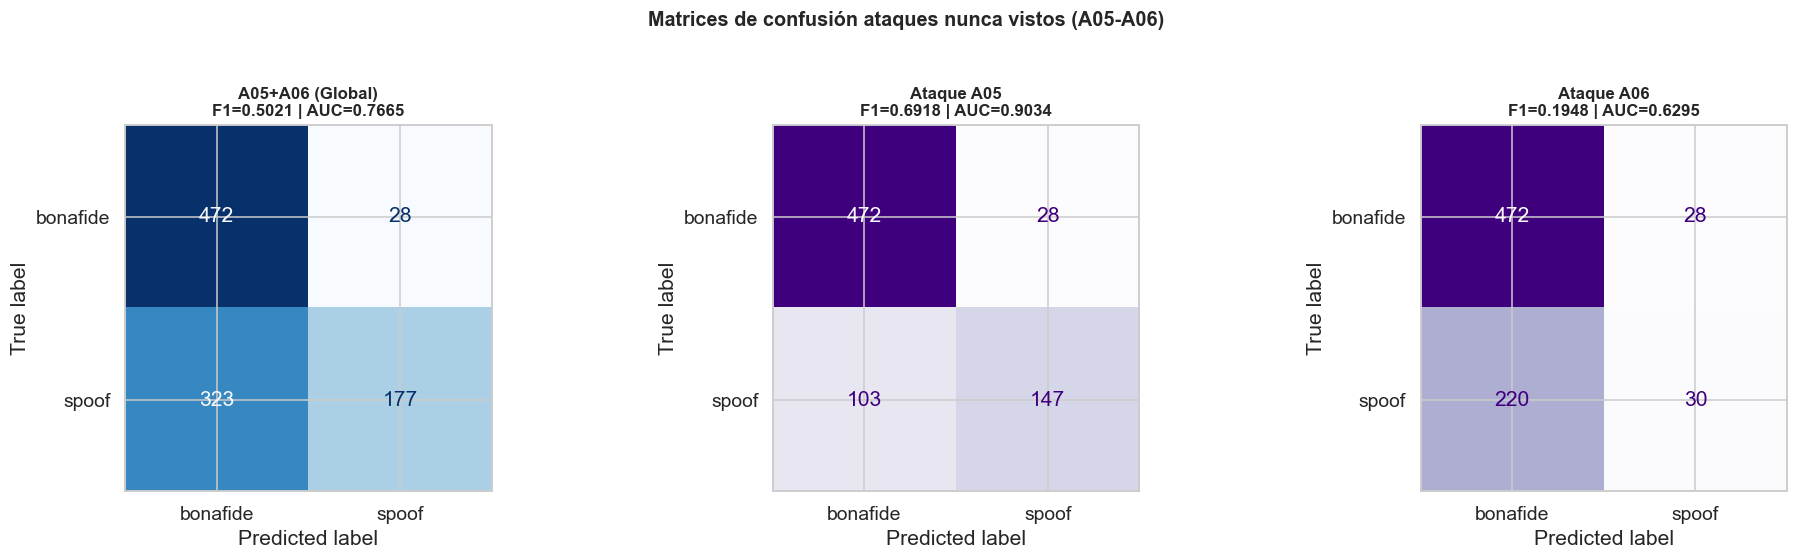

 Hemos guardado el gráfico en el archivo: modelo4_confusion_matrices.png


In [8]:
#  BLOQUE 8: MATRICES DE CONFUSIÓN (GLOBAL + INDIVIDUAL POR ATAQUE)

ncols = 1 + len(TEST_ATTACKS)
fig, axes = plt.subplots(1, ncols, figsize=(6 * ncols, 5))

# Panel 1: confusión global
cm_global = confusion_matrix(y_test_enc, y_pred)
ConfusionMatrixDisplay(cm_global, display_labels=['bonafide', 'spoof']).plot(
    ax=axes[0], colorbar=False, cmap='Blues'
)
axes[0].set_title(f'A05+A06 (Global)\nF1={test_metrics["f1"]:.4f} | AUC={test_metrics["roc_auc"]:.4f}',
                  fontsize=11)

# Paneles 2: confusión por ataque
for ax, row in zip(axes[1:], per_attack_results):
    atk  = row['Ataque']
    mask = (df_test['attack_id'] == atk) | (df_test['label'] == 'bonafide')
    y_a  = y_test_enc[mask]
    p_a  = model.predict(X_test[mask])
    cm_a = confusion_matrix(y_a, p_a)
    ConfusionMatrixDisplay(cm_a, display_labels=['bonafide', 'spoof']).plot(
        ax=ax, colorbar=False, cmap='Purples'
    )
    ax.set_title(f'Ataque {atk}\nF1={row["F1"]:.4f} | AUC={row["AUC"]:.4f}', fontsize=11)

plt.suptitle('Matrices de confusión ataques nunca vistos (A05-A06)', y=1.02, fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('modelo4_confusion_matrices.png', bbox_inches='tight', dpi=120)
plt.show()
print(' Hemos guardado el gráfico en el archivo: modelo4_confusion_matrices.png')

### **Comentarios sobre matrices de confusión**

***Que nos muestra la matriz de confusión global (A05+A06)?***  

La matriz de confusión global, nos indica que con un F1-score de 0.51 sobre el conjunto de test global, observamos que cuando el algoritmo predice que un audio es spoof acierta en el 86,34% (precision), pero cuando tiene que detectar sobre todo el conjunto real de audios spoof (tanto A05-A06 como bonafide) si un audio es sintetico, se equivoca 323 veces sobre 500 (se equivoca en un 64,60%, esta es la recall global). O sea, 323 audios spoof se predicen como bonafide.

***Que pasa cuando separamos A05 y A06?***

Notamos que bonafide es idéntica en las 3 matrices de confusión: cuando el audio es bonafide el algoritmo acierta 472 veces y se equivoca solo en 28 ocasiones. 

Cuando el ataque es el A05, de 250 spoof A05, 147 audios están bien detectados y 103 los detecta como bonafide. Aquí el modelo tiene una recall del 58.80% y por lo menos predice bien más del 50% de los audios spoof generados por A05.

Cuando el ataque es A06, de 250 spoof, solo 30 de 250 son los audios bien detectados. 
Casi todo el resultado no positivo del global depende de como el modelo detecta los audios spoof A06.

### ***Bloque 9: CURVA ROC A01-A04 (CV) y CURVA ROC A05-A06 GLOBAL Y INDIVIDUAL***

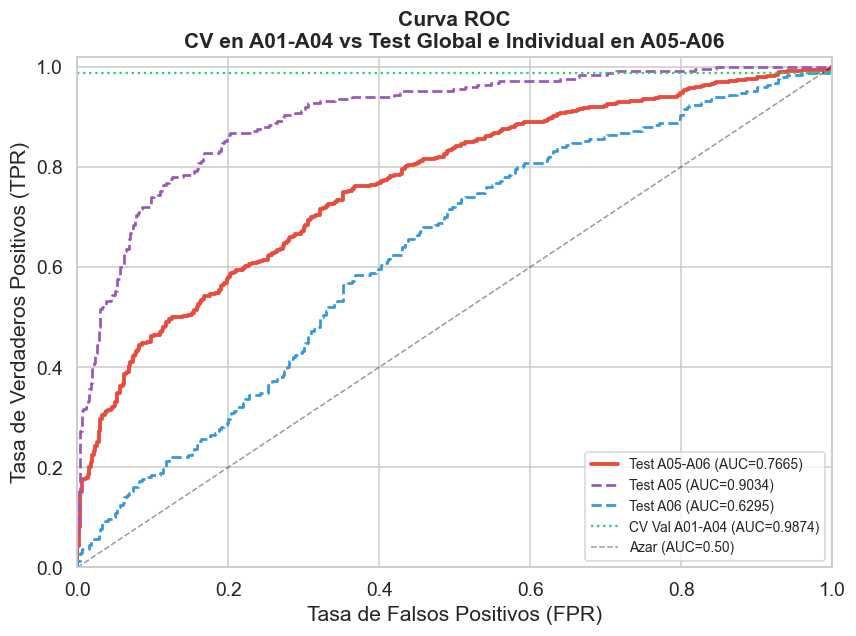

Gráfico guardado en el archivo modelo4_roc_curve.png


In [9]:
#  Bloque 9: CURVA ROC: A01-A04 (CV) vs A05-A06 (Test) GLOBAL Y INDIVIDUAL

fig, ax = plt.subplots(figsize=(8, 6))

# ROC en test global A05+A06
fpr_test, tpr_test, _ = roc_curve(y_test_enc, y_pred_proba)
ax.plot(fpr_test, tpr_test, lw=2.5, color='#e74c3c',
        label=f'Test A05-A06 (AUC={test_metrics["roc_auc"]:.4f})')

# ROC por ataque individual
colors_atk = ['#9b59b6', '#3498db']
for row, col in zip(per_attack_results, colors_atk):
    atk  = row['Ataque']
    mask = (df_test['attack_id'] == atk) | (df_test['label'] == 'bonafide')
    y_a  = y_test_enc[mask]
    p_a  = model.predict_proba(X_test[mask])[:, 1]
    fpr_a, tpr_a, _ = roc_curve(y_a, p_a)
    ax.plot(fpr_a, tpr_a, lw=1.8, linestyle='--', color=col,
            label=f'Test {atk} (AUC={row["AUC"]:.4f})')

# CV en A01-A04
ax.axhline(cv_results['test_roc_auc'].mean(), color='#2ecc71', ls=':',
           lw=1.5, label=f'CV Val A01-A04 (AUC={cv_auc_val:.4f})')

ax.plot([0,1],[0,1], 'k--', lw=1, alpha=0.4, label='Azar (AUC=0.50)')
ax.set_xlabel('Tasa de Falsos Positivos (FPR)')
ax.set_ylabel('Tasa de Verdaderos Positivos (TPR)')
ax.set_title('Curva ROC\nCV en A01-A04 vs Test Global e Individual en A05-A06')
ax.legend(loc='lower right', fontsize=9)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])

plt.tight_layout()
plt.savefig('modelo4_roc_curve.png', bbox_inches='tight', dpi=120)
plt.show()
print('Gráfico guardado en el archivo modelo4_roc_curve.png')

### **Comentarios sobre Curva ROC (CV train vs test global e individual)**

- **CV sobre el conjunto de train (spoof A01–A04 + bonafide** con **AUC ≈ 0,987)**: el modelo separa muy bien audios bonafide y spoof dentro de la distribución de entrenamiento.

- **Test global A05–A06 (AUC ≈ 0,77)**: al mezclar los dos ataques, el ranking sigue por encima del azar, pero muy por debajo de la CV.  

- **Test solo A05 (AUC ≈ 0,90)**: hay una buena separación entre clases.

- **Test solo A06 (AUC ≈ 0,63)**: la capacidad discriminativa es débil y la curva se acerca mucho más a la diagonal que el resto, justificando que no separa bien las clases.

### ***Bloque 10: FEATURE IMPORTANCE CON PERMUTACIÓN***

Calculando Permutation Importance sobre A05-A06 (ataques no vistos):


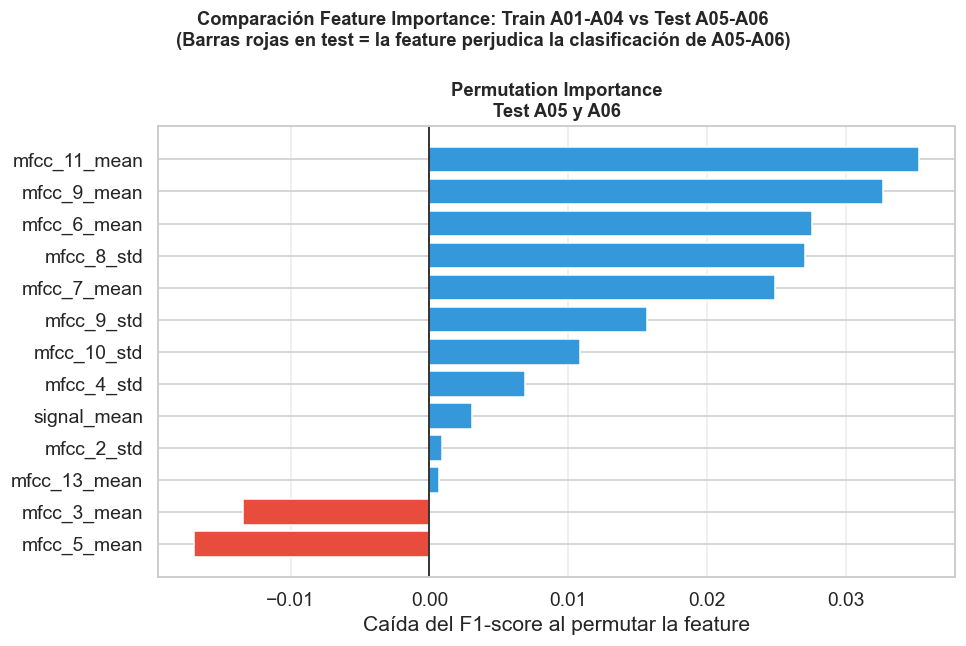

Gráfico guardado: modelo4_feature_importance.png

Permutation Importance - Test A05-A06:
  [+] mfcc_11_mean                   +0.0353
  [+] mfcc_9_mean                    +0.0327
  [+] mfcc_6_mean                    +0.0275
  [+] mfcc_8_std                     +0.0271
  [+] mfcc_7_mean                    +0.0249
  [+] mfcc_9_std                     +0.0157
  [+] mfcc_10_std                    +0.0108
  [+] mfcc_4_std                     +0.0069
  [+] signal_mean                    +0.0031
  [+] mfcc_2_std                     +0.0009
  [+] mfcc_13_mean                   +0.0007
  [-] mfcc_3_mean                    -0.0134
  [-] mfcc_5_mean                    -0.0170

Features que perjudican en A05-A06:
mfcc_3_mean                    -0.0134
mfcc_5_mean                    -0.0170


In [10]:
#  Bloque 10: FEATURE IMPORTANCE

print('Calculando Permutation Importance sobre A05-A06 (ataques no vistos):')

perm_imp = permutation_importance(
    model, X_test, y_test_enc,
    n_repeats=15, random_state=RANDOM_STATE,
    scoring='f1', n_jobs=-1
)

fi_test = pd.Series(
    perm_imp.importances_mean,
    index=FINAL_FEATURES
).sort_values(ascending=False)

fi_test_sorted = fi_test.sort_values()
colors_perm = ['#e74c3c' if v < 0 else '#3498db' for v in fi_test_sorted.values]

fig, ax = plt.subplots(figsize=(9, 6))

# Panel derecho: Permutation Importance (test A05-A06)
ax.barh(fi_test_sorted.index, fi_test_sorted.values, color=colors_perm, edgecolor='white')
ax.axvline(0, color='black', lw=1)
ax.set_title('Permutation Importance\nTest A05 y A06', fontsize=12)
ax.set_xlabel('Caída del F1-score al permutar la feature')
ax.grid(axis='x', alpha=0.4)

plt.suptitle('Comparación Feature Importance: Train A01-A04 vs Test A05-A06\n'
             '(Barras rojas en test = la feature perjudica la clasificación de A05-A06)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('modelo4_feature_importance.png', bbox_inches='tight', dpi=120)
plt.show()
print('Gráfico guardado: modelo4_feature_importance.png')
print()
print('Permutation Importance - Test A05-A06:')
for feat, val in fi_test.sort_values(ascending=False).items():
    marker = '+' if val > 0 else '-'
    print(f'  [{marker}] {feat:<30} {val:+.4f}')
print()
print('Features que perjudican en A05-A06:')
neg_feats = fi_test[fi_test < 0]
if len(neg_feats) == 0:
    print('Ninguna feature tiene importancia negativa')
else:
    for feat, val in neg_feats.items():
        print(f'{feat:<30} {val:+.4f}')

## **SECCIÓN 6**: Comparativa Final: TRAIN (A01-A04 + bonafide) vs TEST (A5, A06 + bonafide)

***Cómo interpretamos el cuadro comparativo completo?***  

Vamos a comparar según los siguientes tres niveles: el rendimiento dentro de A01-A04 con datos vistos en train, el rendimiento en CV (datos de A01-A04 no vistos en ese fold) y el rendimiento en A05-A06 (ataques completamente nuevos). La caída gradual entre niveles nos dice cuánto del rendimiento del modelo es interpolación (del nivel 1 al nivel 2) o extrapolación (del nivel 2 al nivel 3).

La interpolación es cuando el modelo se evalúa dentro del conjunto de entrenamiento, aunque en CV no haya visto una parte de los datos, que usa para validar.

La extrapolación es cuando el modelo se prueba fuera de la región de entrenamiento: tipos de ataque (A05–A06) que no formaron parte del aprendizaje, como en A01–A4.  

**Qué acción tomar según el resultado?**  

- Si F1 en A05-A06 ≥ 0.85 llevamos el modelo a producción con confianza;
- Si F1 entre 0.70-0.85 habría que ampliar el dataset de entrenamiento con más variedad de ataques;
- Si F1 < 0.70: rediseñar las features o explorar técnicas de domain adaptation.

### ***Bloque 11: GRÁFICO TRAIN (A01-A04 + bonafide) vs TEST (A05, A06 + bonafide)***

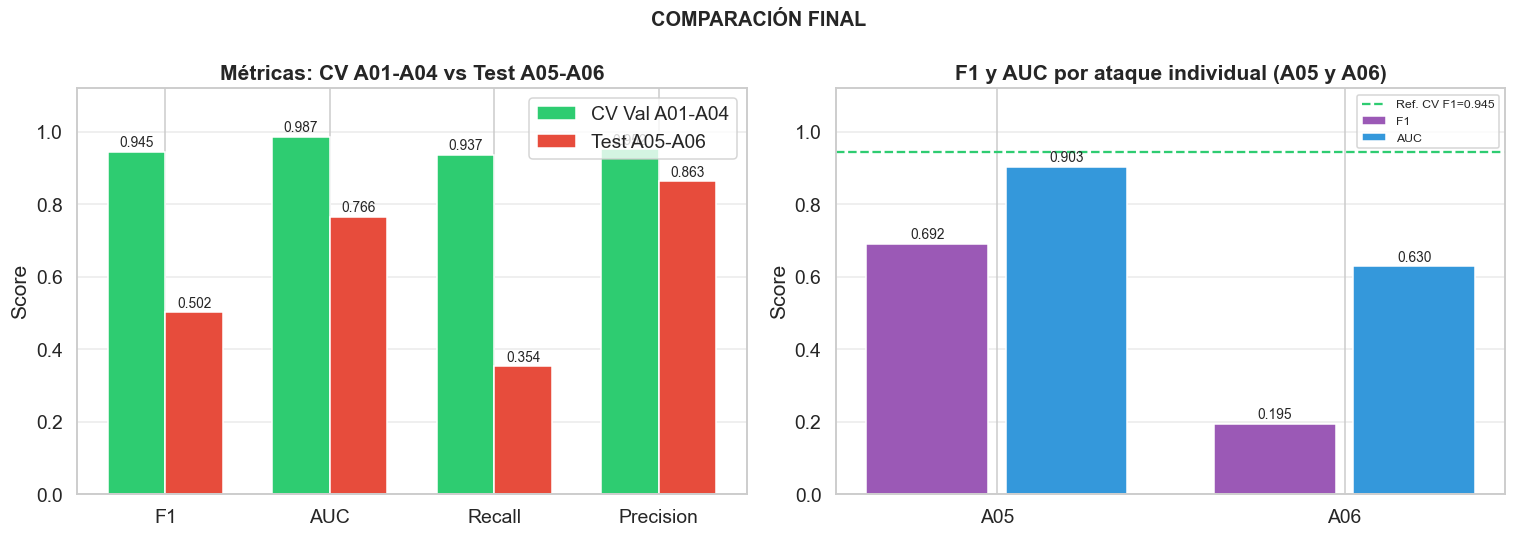

Gráfico guardado: modelo4_comparativa_final.png


In [11]:
#  Bloque 11: GRÁFICO COMPARATIVO: TRAIN vs UNSEEN

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: Barras comparativas de métricas
metrics_labels = ['F1', 'AUC', 'Recall', 'Precision']
cv_vals   = [
    cv_results['test_f1'].mean(),
    cv_results['test_roc_auc'].mean(),
    cv_results['test_recall'].mean(),
    cv_results['test_precision'].mean()
]
test_vals = [
    test_metrics['f1'],
    test_metrics['roc_auc'],
    test_metrics['recall'],
    test_metrics['precision']
]

x    = np.arange(len(metrics_labels))
w    = 0.35
bars1 = axes[0].bar(x - w/2, cv_vals,   w, label='CV Val A01-A04', color='#2ecc71', edgecolor='white')
bars2 = axes[0].bar(x + w/2, test_vals, w, label='Test A05-A06',   color='#e74c3c', edgecolor='white')

for bar in bars1:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics_labels)
axes[0].set_ylim([0.0, 1.12])
axes[0].set_ylabel('Score')
axes[0].set_title('Métricas: CV A01-A04 vs Test A05-A06')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.4)

# Panel 2: F1 por ataque individual
ataque_labels = [r['Ataque'] for r in per_attack_results]
ataque_f1s    = [r['F1']     for r in per_attack_results]
ataque_aucs   = [r['AUC']    for r in per_attack_results]

xb = np.arange(len(ataque_labels))
axes[1].bar(xb - 0.2, ataque_f1s,  0.35, label='F1',  color='#9b59b6', edgecolor='white')
axes[1].bar(xb + 0.2, ataque_aucs, 0.35, label='AUC', color='#3498db', edgecolor='white')

for i, (f1, auc) in enumerate(zip(ataque_f1s, ataque_aucs)):
    axes[1].text(i - 0.2, f1  + 0.005, f'{f1:.3f}',  ha='center', va='bottom', fontsize=9)
    axes[1].text(i + 0.2, auc + 0.005, f'{auc:.3f}', ha='center', va='bottom', fontsize=9)

axes[1].set_xticks(xb)
axes[1].set_xticklabels(ataque_labels)
axes[1].set_ylim([0.0, 1.12])
axes[1].set_ylabel('Score')
axes[1].set_title('F1 y AUC por ataque individual (A05 y A06)')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.4)

# Línea de referencia CV
axes[1].axhline(cv_results['test_f1'].mean(), color='#2ecc71', ls='--',
                lw=1.5, label=f'Ref. CV F1={cv_f1_val:.3f}')
axes[1].legend(fontsize=8)

plt.suptitle('COMPARACIÓN FINAL', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('modelo4_comparativa_final.png', bbox_inches='tight', dpi=120)
plt.show()
print('Gráfico guardado: modelo4_comparativa_final.png')

### ***Bloque 12: TABLA RESUMEN DE LOS 4 MODELOS QUE REALIZAMOS***

In [20]:
#  Bloque 12: TABLA RESUMEN COMPLETA M1 → M2 → M3 → M4

resumen = pd.DataFrame([
    {
        'Modelo'      : 'M1 - XGBoost base',
        'N Train'     : '4,000',
        'N Features'  : '34',
        'Tipo test'   : 'Aleatorio (A01-A06)',
        'CV Val F1'   : 0.9452,
        'Test F1'     : 0.9543,
        'Test AUC'    : 0.9897
    },
    {
        'Modelo'      : 'M2 - XGBoost (N optimo + HP optimo)',
        'N Train'     : '4,000',
        'N Features'  : '34',
        'Tipo test'   : 'Aleatorio (A01-A06)',
        'CV Val F1'   : 0.9484,
        'Test F1'     : 0.9546,
        'Test AUC'    : 0.9922
    },
    {
        'Modelo'      : 'M3 - XGBoost (13 features optimas)',
        'N Train'     : '4,000',
        'N Features'  : '13',
        'Tipo test'   : 'Aleatorio (A01-A06)',
        'CV Val F1'   : 0.9093,
        'Test F1'     : 0.9032,
        'Test AUC'    : 0.9700
    },
    {
        'Modelo'      : 'M4 - XGBoost (A05 y A06 no vistos)',
        'N Train'     : f'{len(df_train):,}',
        'N Features'  : '13',
        'Tipo test'   : 'A05 y A06 NUNCA VISTOS',
        'CV Val F1'   : round(cv_f1_val, 4),
        'Test F1'     : round(test_metrics['f1'], 4),
        'Test AUC'    : round(test_metrics['roc_auc'], 4),
    }
])

print('=' * 113)
print('EVOLUCIÓN COMPLETA: M1 → M2 → M3 → M4')
print('=' * 113)
print(resumen.to_string(index=False))
print()
print('CONCLUSIÓN FINAL:')
print(f'{veredicto}')

EVOLUCIÓN COMPLETA: M1 → M2 → M3 → M4
                             Modelo N Train N Features              Tipo test  CV Val F1  Test F1  Test AUC
                  M1 - XGBoost base   4,000         34    Aleatorio (A01-A06)     0.9452   0.9543    0.9897
M2 - XGBoost (N optimo + HP optimo)   4,000         34    Aleatorio (A01-A06)     0.9484   0.9546    0.9922
 M3 - XGBoost (13 features optimas)   4,000         13    Aleatorio (A01-A06)     0.9093   0.9032    0.9700
 M4 - XGBoost (A05 y A06 no vistos)   4,000         13 A05 y A06 NUNCA VISTOS     0.9445   0.5021    0.7665

CONCLUSIÓN FINAL:
SOBREAJUSTE A01-A04: el modelo memorizó patrones y sobreajustó a los primeros 4 ataques


## **CONCLUSIONES DEL MODELO 4**

### Configuración final utilizada

El Modelo 4 evalúa si el XGBoost optimizado (`XGB_OPTIMAL_PARAMS_M1`, 13 features por Permutation Importance) aprendió la diferencia estructural voz humana/sintética, o solo memorizó los patrones acústicos de los 4 primeros sistemas TTS (A01-A04).

| Elemento | Valor |
|----------|-------|
| Algoritmo | XGBoost optimizado (`XGB_OPTIMAL_PARAMS_M1`, Modelo 1) |
| Features | 13 (Permutation Importance, Modelo 3) |
| Train | 4.000 muestras: 2.000 spoof (A01-A04) + 2.000 bonafide (50/50) |
| Test sellado | 1.000 muestras: 500 spoof (A05-A06) + 500 bonafide (50/50) |
| Partición | Estructural por ataque - A05 y A06 nunca vistos en entrenamiento |

### Comparativa de los modelos implementados: M1 → M3 → M4

| Modelo | Descripción | N Train | Features | Tipo test |
|--------|-------------|---------|----------|----------|
| M1 | XGBoost optimizado (RandomizedSearchCV, 34 feat.) | 4.000 | 34 | Aleatorio (A01-A06) |
| M3 | XGBoost optimizado (13 features, Permutation) | 4.000 | 13 (Permutation) | Aleatorio (A01-A06) |
| M4 | XGBoost optimizado | 4.000 | 13 (Permutation) | UNSEEN: A05-A06 |

### ***Observando los modelos como interpretamos los resultados?***

Analizando los resultados obtenidos notamos como el **Modelo 1** (XGBoost optimizado con todas las features mediante `RandomizedSearchCV`) es el modelo que mejor performa con el split aleatorio, logrando el F1-score más alto tanto en CV como en el conjunto de test.

En el modelo 3 realizamos una permutación para calcular las feature importance y vimos que bajando mucho el nivel de computo de datos, obtuvimos un F1-score de 0.91 en CV y de 0.90 en Test (son muy buenos resultados, porque a pesar de haber reducido el F1, el modelo ahora es mucho más sencillo, ligero y se puede utilizar ahorrando muchos calculos computacionales).

En el modelo 4 hicimos algo distinto. En los modelos anteriores (M1 y M3) usamos un split train/test aleatorio: el test contenía ejemplos de todos los ataques (A01-A06) en proporciones similares al train. Eso no es un test de generalización real, es solo un test de interpolación. El modelo 4 nunca ha visto A05 ni A06 durante el entrenamiento. Logramos un F1 en CV elevado (0.9445 que nos dice que en el conjunto A01-A04 el modelo aprende bien los patrones) pero obtuvimos un F1 en el conjunto de test de 0.5021. Esto significa que el modelo sobreajustó los patrones acústicos específicos de A01-A04 y no generaliza bien cuando se encuentra audios que nunca había visto antes (como el A05 y el A06). 
De todas formas vimos que el algoritmo que predice peor es el A06: por cuanto el algoritmo A05 no lo predice muy bien, hace un trabajo seguramente mejor respecto al algoritmo A06, que tiene caracteristicas audio muy distintas de las que el modelo aprendió.

### ***Y que pasa si en lugar de separar train y test de manera fija hicieramos 6 pruebas en bucle?***

Vamos ahora a implementar un ultimo modelo para la primera fase de nuestro proyecto (el modelo 5).

En el modelo 4 separamos el conjunto de Train con 4 algoritmos sinteticos (A01, A02, A03 y A04) y el conjunto de test con 2 ataques fijos (A05 y A06) y obtuvimos un Un único resultado. 

Con elModelo 5 haremos 6 pruebas en bucle. Cada ataque se queda fuera una vez. Al final tendremos media y desviación estándar de las 6 pruebas.

La diferencia clave con el modelo 4 es que el modelo 5 nos dirá si nuestro modelo optimo falla con cualquier ataque que no haya visto.

Y por ultimo, en la parte final del modelo 5, vamos a probar el modelo sobre el set eval y despues sobre los audios que hemos grabado con nuestras voces.

Para este modelo vamos a usar el XGBoost optimizado, pero usaremos 11 features (eliminaremos también las 2 features que desde el grafico de la permutation importance vimos que empeoran el modelo).